# False Data Injection (FDI) Attacks on Sensors

## Overview
False Data Injection (FDI) attacks occur when an adversary intentionally injects incorrect, manipulated, or spoofed sensor readings into a system to cause incorrect state estimation, control decisions, or analytics. FDI is a serious risk in cyber-physical systems (CPS), industrial control systems (ICS), IoT deployments, autonomous vehicles, robotics, and building/environmental monitoring.

## Threat Model
- Attacker goals: cause disruption, conceal events, bias analytics, trigger unsafe control actions, or degrade system performance.
- Attacker capabilities: may have network access, man-in-the-middle position, compromised sensor/node, or the ability to replay or synthesize sensor messages.
- Constraints: varying knowledge of system models, sensor fusion algorithms, timing, and authentication mechanisms.

## Common Attack Techniques
- Replay attacks: resend previously captured valid sensor readings to hide changes.
- Saturation/spoofing: send extreme values (outliers) to trigger alarms or saturate filters.
- Scaled/biased manipulation: add a constant offset or scale sensor values to bias estimates.
- Coordinated multi-sensor injection: manipulate multiple sensors consistently to evade simple plausibility checks and state estimators.
- Time-shift/tampering: alter timestamps or message ordering to break temporal fusion.

## Typical Impact
- Wrong control actions (e.g., unsafe actuator commands).
- Incorrect state estimation (e.g., wrong position, speed, temperature).
- False alarms or suppression of legitimate alarms.
- Long-term model drift and degraded ML models.
- Physical damage, safety hazards, downtime, or loss of trust.

## Detection Strategies
- Redundancy and cross-checks: use multiple independent sensors measuring the same quantity.
- Consistency checks: physics-based plausibility and invariant checking.
- Statistical and anomaly detection: monitor residuals from state estimators (e.g., Kalman filter residuals), use thresholding, clustering, or ML-based anomaly models.
- Time-series correlation: detect replay or timing anomalies by checking entropy, autocorrelation, and sequence uniqueness.
- Cryptographic integrity: message authentication codes (MACs) and signatures to prevent spoofing.

## Mitigation & Hardening
- Authentication and encryption: secure sensor-to-controller communications (TLS/DTLS, secure tokens).
- Secure boot and device attestation: ensure sensor firmware integrity and provenance.
- Rate limiting and freshness checks: reject stale or duplicated messages; use nonces or sequence numbers.
- Diversity and sensor fusion: combine heterogeneous sensors and incorporate physics-based models into fusion algorithms.
- Robust estimators: use outlier-resistant filters and attack-aware state estimation (e.g., robust Kalman filters, sparse attack detection).
- Network segmentation and least privilege: isolate critical sensors and limit access surfaces.
- Monitoring and logging: maintain end-to-end telemetry for post-incident forensics.

## Practical Recommendations
- Threat-model your deployment: identify high-impact sensors and likely attack vectors.
- Apply defense-in-depth: combine cryptography, redundancy, statistical detection, and operator policies.
- Test with adversarial scenarios: simulate replay, spoofing, and coordinated injections during development and drills.
- Keep firmware and keys managed: rotate keys, apply patches, and use secure provisioning.

## Example Scenario (concise)
A temperature sensor in an industrial process is spoofed by adding a constant offset. The control loop reduces cooling because readings appear higher, causing process overheating. Detection: residuals of a model-based estimator rise; mitigation: switch to redundant sensor and trigger fail-safe.

## Further Reading
- Research on attack-aware state estimation and resilient control.
- Industry guidance on ICS/SCADA security and IoT device hardening.


In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle as pkl
import matplotlib.pyplot as plt

current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

sys.path.insert(0, os.path.abspath(libs_dir))
sys.path.insert(0, os.path.abspath(dataset_dir))
sys.path.insert(0, os.path.abspath(models_dir))

print("Libs directory:", libs_dir)
print("Dataset directory:", dataset_dir)
print("Models directory:", models_dir)

from kelmanfilter import KalmanFilter1D, KalmanFilter2D
from websocketclient import WebSocketCollector, SensorStream
from visualizer import Visualizer

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../libs
Dataset directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../datasets
Models directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/notebooks/../models


## Kalman Filter

In [2]:
collector = WebSocketCollector(ws_url, max_messages=100)
collector.collect()

WebSocket opened
WebSocket closed None


In [3]:
stream =SensorStream(collector.queue)
df = stream.get_as_dataframe()

real_temperature_values = df[['Temperature Sensor']].astype(float).values.flatten()
real_temperature_values = [_ for _ in real_temperature_values if not np.isnan(_)]
df.head()

,Sonar Sensor,Actual_Sonar Sensor,Velocity Sensor,Actual_Velocity Sensor,Temperature Sensor,Actual_Temperature Sensor,Temperature Sensor,Actual_Temperature Sensor
0,NaN,NaN,NaN,NaN,50.784408,45.6,NaN,NaN
1,NaN,NaN,NaN,NaN,38.071755,45.6,NaN,NaN
2,NaN,NaN,NaN,NaN,46.943241,45.6,NaN,NaN
3,NaN,NaN,NaN,NaN,38.866352,45.6,NaN,NaN
4,NaN,NaN,NaN,NaN,40.307320,45.6,NaN,NaN


In [97]:
kf = KalmanFilter1D(dt=0.1, X0=0.0, Q0=1e-10, R0=1e-3)
filtered_values = kf.filter(real_temperature_values)

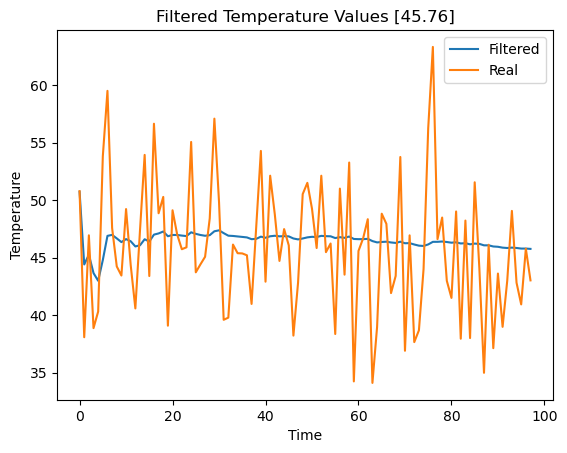

In [98]:
plt.plot(filtered_values, label='Filtered')
plt.plot(real_temperature_values, label='Real')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(filtered_values[-1], 2)}]')
plt.legend()
plt.show()


### FDI Attack

In [96]:
sniffer = WebSocketCollector(ws_url, max_messages=100)
sniffer.collect()

WebSocket opened
WebSocket closed None


In [99]:
stream =SensorStream(sniffer.queue)
df = stream.get_as_dataframe()

sniffed_temperature_values = df[['Temperature Sensor']].astype(float).values.flatten()
sniffed_temperature_values = [_ for _ in sniffed_temperature_values if not np.isnan(_)]

df.head()

,Sonar Sensor,Actual_Sonar Sensor,Velocity Sensor,Actual_Velocity Sensor,Temperature Sensor,Actual_Temperature Sensor,Temperature Sensor,Actual_Temperature Sensor
0,NaN,NaN,NaN,NaN,52.268047,45.6,137.781541,136.6
1,NaN,NaN,NaN,NaN,54.900209,45.6,142.757591,136.6
2,NaN,NaN,NaN,NaN,41.397376,45.6,140.040574,136.6
3,NaN,NaN,NaN,NaN,43.817635,45.6,136.3339,136.6
4,NaN,NaN,NaN,NaN,51.210553,45.6,123.582216,136.6


In [100]:
kf = KalmanFilter1D(dt=0.1, X0=0.0, Q0=1e-10, R0=1e-3)
sniffer_filtered_values = kf.filter(sniffed_temperature_values)

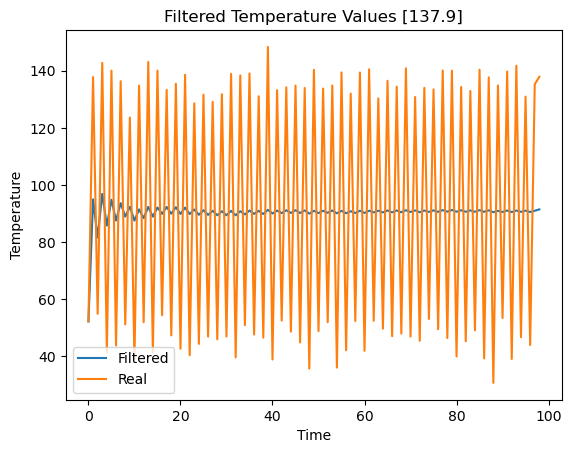

In [104]:
plt.plot(sniffer_filtered_values, label='Filtered')
plt.plot(sniffed_temperature_values, label='Real')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(sniffed_temperature_values[-1], 2)}]')
plt.legend()
plt.show()

## Machine Learning Models

### Training the model with actual data

In [11]:
df = pd.read_csv(dataset_dir + "/Temperature_sensor_real_data.csv")
df.head()

,timestamp,value,actual_value
0,2026-07-08T21:49:57.921872,100.000000,100.0
1,2026-07-08T21:49:58.023360,94.835274,100.0
2,2026-07-08T21:49:58.124900,100.000000,100.0
3,2026-07-08T21:49:58.226210,97.473312,100.0
4,2026-07-08T21:49:58.327960,100.000000,100.0


In [12]:
vs = Visualizer()
vs.describe_data(df)

describing data...
            value  actual_value
count  222.000000    222.000000
mean    63.347908     63.099550
std     34.889232     35.187461
min      0.000000      1.300000
25%     32.669662     34.600000
50%     74.436137     78.950000
75%     94.646513     91.500000
max    100.000000    100.000000
info...
<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     222 non-null    str    
 1   value         222 non-null    float64
 2   actual_value  222 non-null    float64
dtypes: float64(2), str(1)
memory usage: 5.3 KB
None
data types...
timestamp           str
value           float64
actual_value    float64
dtype: object
isnull...
timestamp       0
value           0
actual_value    0
dtype: int64
duplicates...
0


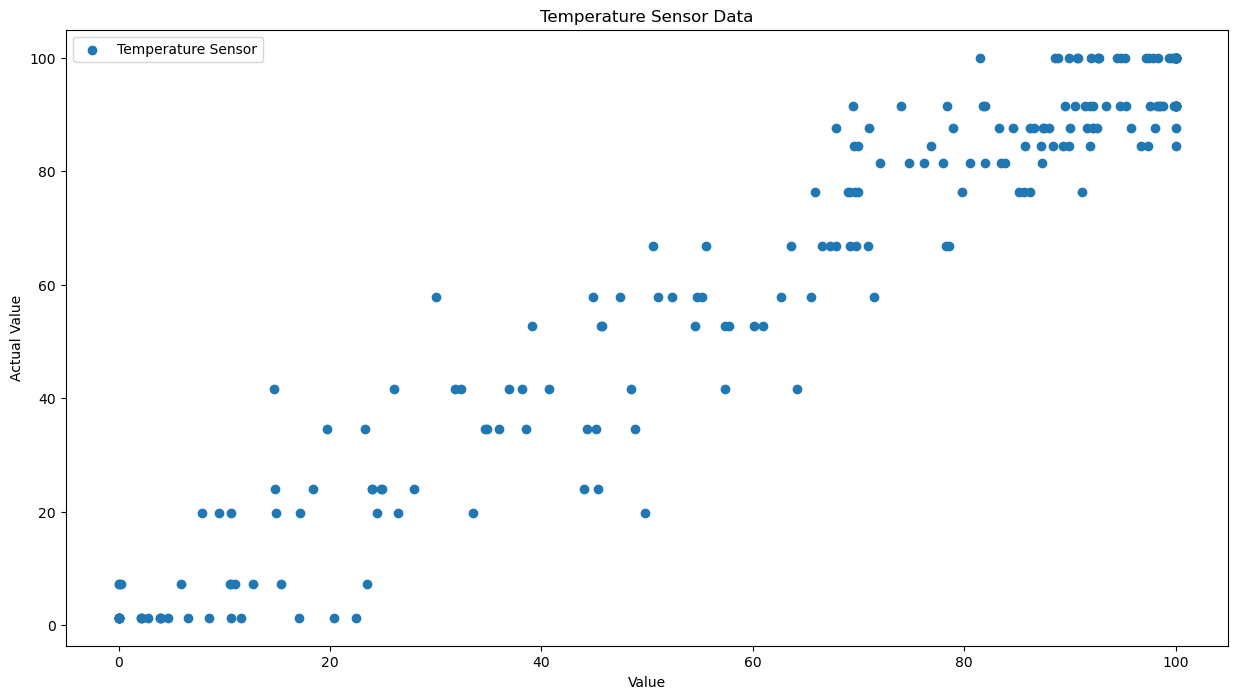

In [13]:
data = [{

            'X': df[['value']].astype(float).values.flatten(),
            'Y': df[['actual_value']].astype(float).values.flatten(),
            'name': 'Temperature Sensor',
            'x_label': 'Value',
            'y_label': 'Actual Value'
        }]

vs.visualize_raw_data(data=data, title="Temperature Sensor Data", x_label="Value", y_label="Actual Value")

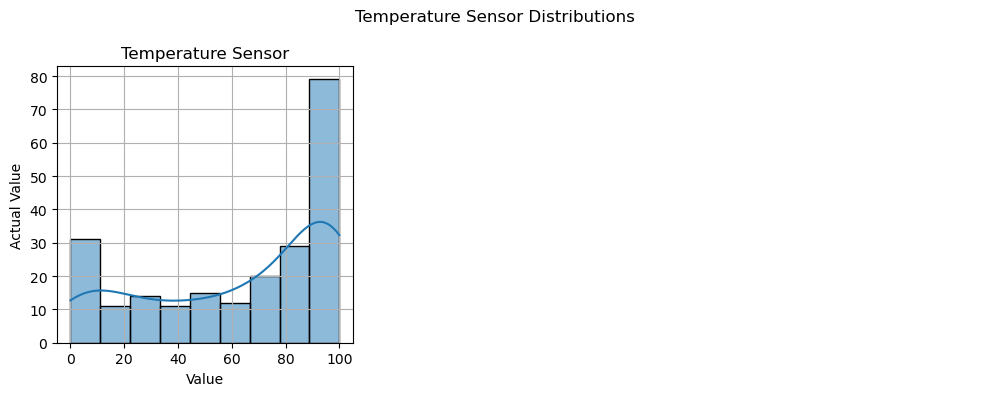

In [14]:
vs.visualize_distributions(data=data, figsize=(10,4), title="Temperature Sensor Distributions", grid=True)

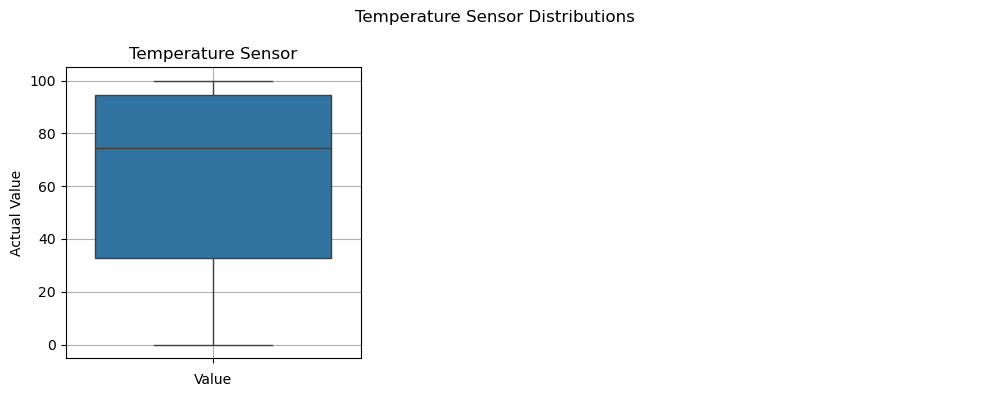

In [15]:
vs.visualize_outliers(data=data, figsize=(10,4), title="Temperature Sensor Distributions", grid=True)

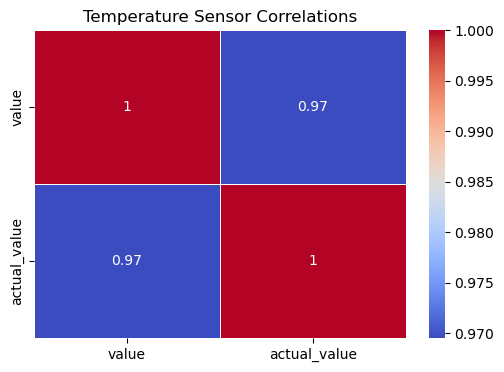

In [16]:
vs.visualize_correlations(df=df[['value','actual_value']], figsize=(6,4), title="Temperature Sensor Correlations", method="pearson")

In [26]:
X = df[['value']].values.reshape(-1, 1)
Y = df[['actual_value']]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(max_iter=500, random_state=42))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(5,10)],
    'mlp__alpha': [0.0001, 0.001]
}

model = MLPRegressor(max_iter=100, random_state=42)
gs = GridSearchCV(mlp_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=1)

gs.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/Users/kolithawarnakulasooriya/miniconda3/envs/ee506/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/kolithawarnakulasooriya/miniconda3/envs/ee506/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/kolithawarnakulasooriya/miniconda3/envs/ee506/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/kolithawarnakulasooriya/miniconda3/envs/ee506/lib/python3.14/site-pack

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__alpha': [0.0001, 0.001], 'mlp__hidden_layer_sizes': [(5, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_se

In [82]:
y_pred = gs.best_estimator_.predict(X_test)

In [83]:
pkl.dump(gs.best_estimator_, open(f'{models_dir}/TemperatureSensorModel.pkl', 'wb'))

### Loading the model from file

In [84]:
model = pkl.load(open(f'{models_dir}/TemperatureSensorModel.pkl', 'rb'))
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1,)",[61.84]


In [91]:

X = np.array(real_temperature_values).reshape(-1, 1)
predicted_values = model.predict(X)
predicted_values = predicted_values + 30

<function matplotlib.pyplot.show(close=None, block=None)>

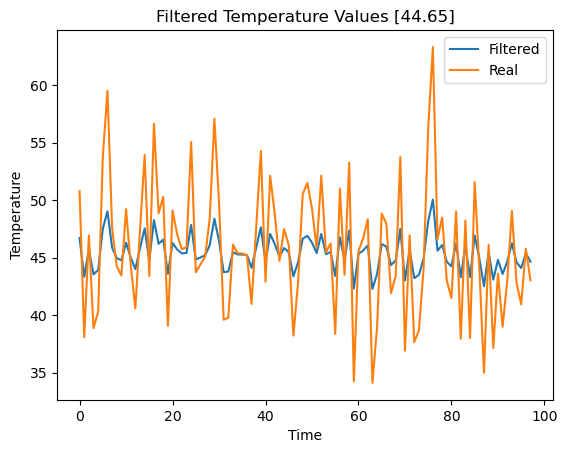

In [92]:
plt.plot(predicted_values, label='Filtered')
plt.plot(real_temperature_values, label='Real')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(predicted_values[-1], 2)}]')
plt.legend()
plt.show

In [102]:
X = np.array(sniffed_temperature_values).reshape(-1, 1)
predicted_values = model.predict(X)
predicted_values = predicted_values + 30

<function matplotlib.pyplot.show(close=None, block=None)>

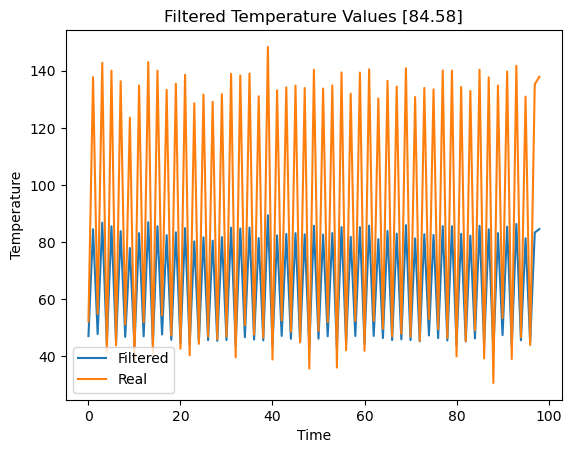

In [103]:
plt.plot(predicted_values, label='Filtered')
plt.plot(sniffed_temperature_values, label='Real')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(predicted_values[-1], 2)}]')
plt.legend()
plt.show

### Best Approach

In [ ]:
X = np.array(sniffed_temperature_values).reshape(-1, 1)
predicted_values = model.predict(X)
predicted_values = predicted_values + 30

filtered_values = kf.filter(predicted_values)

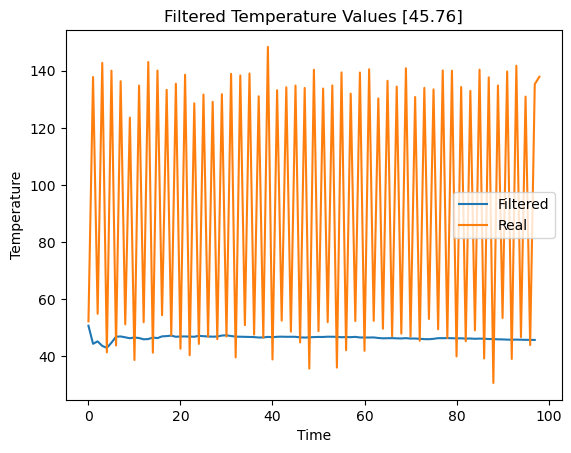

In [106]:
plt.plot(filtered_values, label='Filtered')
plt.plot(sniffed_temperature_values, label='Real')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title(f'Filtered Temperature Values [{round(filtered_values[-1], 2)}]')
plt.legend()
plt.show()